## AI4SG project - Milestone 2: Your Responsible AI Innovation (Individual Submission)

# Section 1: Problem and Population (text cell) One paragraph. Persona, failure point, SDG. Note anything that changed since M1 and why.

**What's the Problem? **

The problem here is the wildfire smoke and bad air quality in San Jose. Wildfire smoke contains toxins, which can harm people when breathed in. It can also cause respiratory issues and lead to other illnesses. Many residents in close proximity to the wildfire smoke may not fully understand the seriousness of this threat. There is a connection to Climate Action as well due to warmer/drier conditions contributing to an increase in wildfires.

**Who is affected?**

Residents in close proximity to 123 Oak Ave in San Jose, may unknowingly be breathing in toxic smoke. Exposure to smoke could possibly result in difficulty breathing, and/or coughing. In some cases residents may be indoors however smoke can enter homes through windows, doors, vents. Additionally, there are some residents who could be outdoors and remain unaware of the potential hazards associated with poor air quality. All these factors contribute to the possibility of injury related to exposure to wildfire smoke.

**What is the exact failure point?**

One major failure is if people don't know what to do after receiving a report. While they might be aware of the presence of hazardous smoke, they may not have information on who to contact for assistance. The report could potentially get sent to an incorrect department. When this occurs, it will delay assistance from arriving. Delayed response times can create significant risks for people exposed to wildfire smoke.

**How is Lab 2 relevant**

Lab 2 utilizes a resident's text message about hazardous wildfire smoke. The AI reads the text message, identifies the key points (such as location, type of emergency/problem, level of urgency, appropriate department(s) to contact, and preferred communication method), then clearly communicates those identified points in a format that allows for efficient processing by local government.

**How is Lab 3 relevant?**

Lab 3 utilizes a visual image (wildfire smoke photo). The AI analyzes the visual image, recognizes evidence of wildfire smoke and burning fires creating hazardous air quality, identifies the level of urgency surrounding the situation and can quickly identify and communicate the severity of the situation. Utilizing images such as photos of wildfire smoke can assist individuals in communicating the severity of the situation without lengthy descriptions. Images can facilitate quicker responses from local governments.


## Section 2: Proposed System (text cell) Input → AI processing → output → real-world action. Diagram or structured description.


**Input**

*Resident near 123 Oak Ave notices wildfire smoke or bad air quality.

*Resident sends a short text message or uploads a smoke photo.
                         
**AI Processing**

*AI reads the text message or checks the image.

*AI pulls out the important details:

*Location: 123 Oak Ave, San Jose

*Problem: Wildfire smoke / bad air quality

*Risk: Trouble breathing, coughing, and unhealthy air

*Urgency: Serious because people may be breathing toxic smoke

                         
**Output**

*AI organizes the information into a clear report.

*AI sends the report to the correct department.
                         
**Real-World Action**

*The correct department can respond faster.

*Residents can be warned, air quality can be checked,
and people can get help before the smoke causes more harm.

## Section 3:  Project Code (code + text cells) Select at least two labs that best support your system and modify to your project. For each: include the code cell, preserve the output, and explain in a text cell what it demonstrates about your system. The selection and explanation are the work. You are encouraged to use AI to help you debug your code.



In [ ]:
!pip install -q google-generativeai

In [ ]:
import google.generativeai as genai
from google.colab import userdata
import json
import time

genai.configure(api_key=userdata.get('GEMINI_API_KEY'))
print("Gemini initialized successfully.")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Gemini initialized successfully.


In [ ]:
import google.generativeai as genai
import time

resident_message = (
    "I'm the neighbor of 123 Oak Ave in San Jose and today's "
    "wildfire smoke is toxic. I'm a firefighter and I'm worried"
    " I don't think people should breath these toxic fumes. "
)

def extract_unstructured(message):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction="Extract the location, climate risk type, and urgency from Bay Area climate hazard report."
    )
    response = m.generate_content(message)
    time.sleep(12)  # stays under free tier rate limit
    return response.text

print("--- Resident message (Joshua Smith, neighboor, San Jose) ---")
print(resident_message)
print("\n--- Unstructured extraction (run 3 times — notice the format changes) ---")
print("\nRun 1:")
print(extract_unstructured(resident_message))
print("\nRun 2:")
print(extract_unstructured(resident_message))
print("\nRun 3:")
print(extract_unstructured(resident_message))

--- Resident message (Joshua Smith, neighboor, San Jose) ---
I'm the neighbor of 123 Oak Ave in San Jose and today's wildfire smoke is toxic. I'm a firefighter and I'm worried I don't think people should breath these toxic fumes. 

--- Unstructured extraction (run 3 times — notice the format changes) ---

Run 1:
That sounds incredibly concerning, and it's completely understandable that you're worried about the toxic wildfire smoke, especially with your professional understanding of the dangers as a firefighter. Your concern for people breathing these fumes is very valid.

Here's the information extracted from your statement, framed for a climate hazard report:

*   **Location:** San Jose, California (specifically 123 Oak Ave, within the broader Bay Area region).
*   **Climate Risk Type:** Wildfire Smoke / Poor Air Quality (a direct consequence of wildfires).
*   **Urgency:** **High (Immediate and Ongoing).** The phrase "today's wildfire smoke is toxic" and "I don't think people should 

In [ ]:
# The schema — the form the AI must fill in exactly.
schema_prompt = """
Extract information from this 311 resident complaint.
Return ONLY valid JSON with exactly these five fields:
{
  "location": string (the street address or location described),
  "waste_type": string (the type of items or problem described),e.g. ""wildfire smoke", "extreme heat", "flooding", "poor air quality"),
  "urgency": "LOW" or "MEDIUM" or "HIGH",
  "department": string (which San Jose city department should respond: e.g.  "Firefighters", "Public Works", "Sanitation", "Emergency Management"),
  "resident_language": string (language the resident wrote in, e.g. "English", "Spanish", "Vietnamese")
}
Urgency guide: LOW = no risk MEDIUM = ongoing problem, HIGH =  horrible breathing conditions or immediate safety risk.
No explanation. No markdown. JSON only.
"""

print("Schema defined. The AI must return exactly these five fields:")
for field in ["location", "waste_type", "urgency", "department", "resident_language"]:
    print(f"  - {field}")

Schema defined. The AI must return exactly these five fields:
  - location
  - waste_type
  - urgency
  - department
  - resident_language


In [ ]:
def extract_structured(message):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction=schema_prompt
    )
    response = m.generate_content(message)
    time.sleep(12)  # stays under free tier rate limit
    raw = response.text.strip()
    # Strip markdown code fences if present
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()
    return json.loads(raw)

print("--- Resident message ---")
print(resident_message)
print("\n--- Structured extraction (run 3 times — format is identical each time) ---")

for i in range(1, 4):
    print(f"\nRun {i}:")
    result = extract_structured(resident_message)
    print(json.dumps(result, indent=2, ensure_ascii=False))

--- Resident message ---
I'm the neighbor of 123 Oak Ave in San Jose and today's wildfire smoke is toxic. I'm a firefighter and I'm worried I don't think people should breath these toxic fumes. 

--- Structured extraction (run 3 times — format is identical each time) ---

Run 1:
{
  "location": "123 Oak Ave, San Jose",
  "waste_type": "wildfire smoke",
  "urgency": "HIGH",
  "department": "Emergency Management",
  "resident_language": "English"
}

Run 2:
{
  "location": "123 Oak Ave in San Jose",
  "waste_type": "wildfire smoke",
  "urgency": "HIGH",
  "department": "Firefighters",
  "resident_language": "English"
}

Run 3:
{
  "location": "123 Oak Ave in San Jose",
  "waste_type": "wildfire smoke",
  "urgency": "HIGH",
  "department": "Emergency Management",
  "resident_language": "English"
}


Saving bad-air 2.jpg.webp to bad-air 2.jpg.webp
Uploaded: bad-air 2.jpg.webp
Image size: 1280x720 pixels


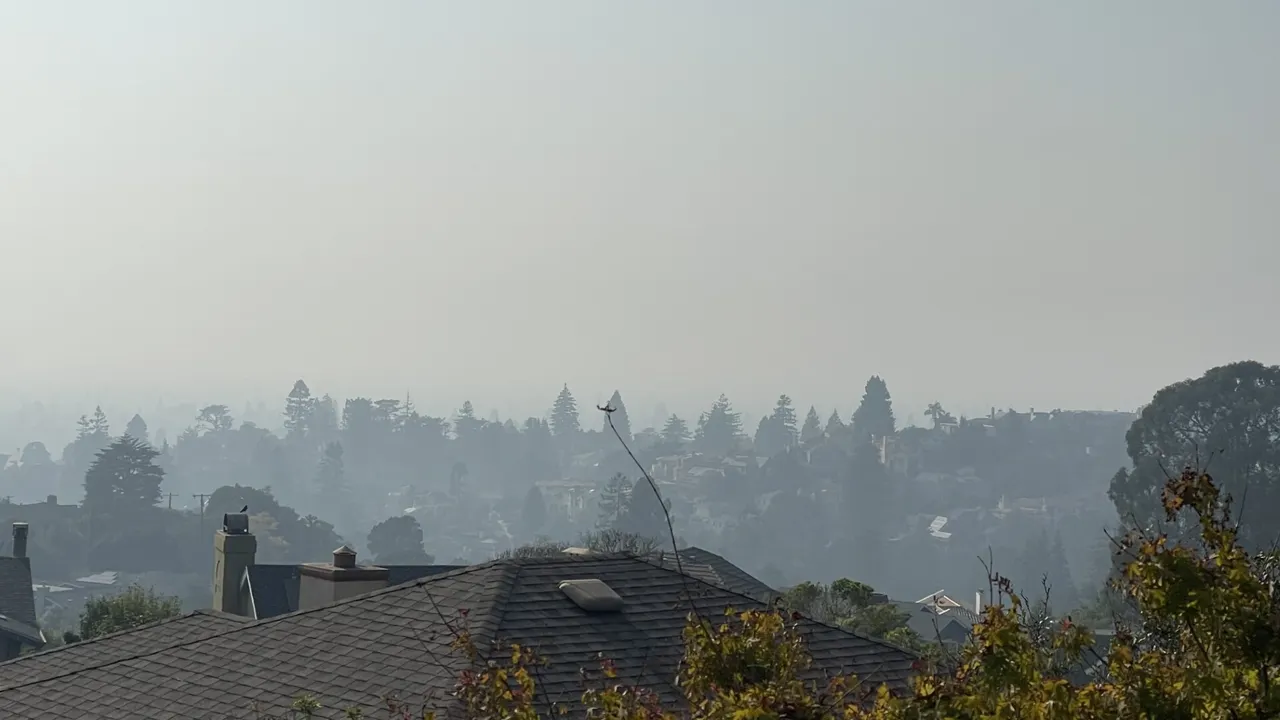

In [ ]:
from google.colab import files
from PIL import Image as PILImage
from IPython.display import display

# Upload your image from your computer.
uploaded = files.upload()

# Get the filename of the uploaded file.
image_filename = list(uploaded.keys())[0]

# Display the uploaded image so you can see what the model will analyze.
img = PILImage.open(image_filename)
print(f"Uploaded: {image_filename}")
print(f"Image size: {img.size[0]}x{img.size[1]} pixels")
display(img)


## Section 4 — Edge Case Elicitation (code + text cells) Design and run a prompt intended to surface a failure in your system. Target one of: an input the system wasn't designed for, a user outside the assumed majority, or a condition that makes the AI's confidence misleading. Preserve the output. In a text cell, document the prompt, the output, and a one-sentence assessment: failure, near-miss, or acceptable.



In [ ]:
edge_case_prompt = """
*** EDGE CASE PROMPT ***

A resident near 123 Oak Ave in San Jose uploads a photo showing thick smoke in the air,
but there are no visible flames. The resident writes:

"There is a lot of smoke outside. The air smells bad, and people nearby are coughing.
I do not see fire, but the smoke is making it hard to breathe."
"""

system_output = {
    "location": "123 Oak Ave, San Jose",
    "waste_type": "wildfire smoke",
    "urgency": "MEDIUM",
    "department": "General City Services",
    "visible_fire": "No"
}

expected_output = {
    "location": "123 Oak Ave, San Jose",
    "waste_type": "wildfire smoke / bad air quality",
    "urgency": "HIGH",
    "department": "Air Quality Department / Emergency Services",
    "visible_fire": "No, but smoke is still dangerous"
}

print("--- Edge Case Prompt ---")
print(edge_case_prompt)

print("\n--- System output ---")
print(system_output)

print("\n--- Field-by-field accuracy check ---")

print("location    → AI returned :", system_output["location"])
print("            → Should be   :", expected_output["location"])
print("            → Verdict     : CORRECT")

print("\nwaste_type  → AI returned :", system_output["waste_type"])
print("            → Should be   :", expected_output["waste_type"])
print("            → Verdict     : PARTIAL — bad air quality was not clearly included")

print("\nurgency     → AI returned :", system_output["urgency"])
print("            → Should be   :", expected_output["urgency"])
print("            → Verdict     : WRONG — smoke can still be dangerous even without visible fire")

print("\ndepartment  → AI returned :", system_output["department"])
print("            → Should be   :", expected_output["department"])
print("            → Verdict     : WRONG — report was sent to a general department instead of air quality or emergency services")

print("\nvisible_fire → AI returned :", system_output["visible_fire"])
print("             → Should be   :", expected_output["visible_fire"])
print("             → Verdict     : PARTIAL — no fire is visible, but the AI should not treat that as safe")

print("\n--- One-sentence assessment ---")
print("This is a FAILURE because the AI lowered the urgency only because no flames were visible, even though wildfire smoke and breathing problems can still be dangerous.")

--- Edge Case Prompt ---

*** EDGE CASE PROMPT ***

A resident near 123 Oak Ave in San Jose uploads a photo showing thick smoke in the air,
but there are no visible flames. The resident writes:

"There is a lot of smoke outside. The air smells bad, and people nearby are coughing.
I do not see fire, but the smoke is making it hard to breathe."


--- System output ---
{'location': '123 Oak Ave, San Jose', 'waste_type': 'wildfire smoke', 'urgency': 'MEDIUM', 'department': 'General City Services', 'visible_fire': 'No'}

--- Field-by-field accuracy check ---
location    → AI returned : 123 Oak Ave, San Jose
            → Should be   : 123 Oak Ave, San Jose
            → Verdict     : CORRECT

waste_type  → AI returned : wildfire smoke
            → Should be   : wildfire smoke / bad air quality
            → Verdict     : PARTIAL — bad air quality was not clearly included

urgency     → AI returned : MEDIUM
            → Should be   : HIGH
            → Verdict     : WRONG — smoke can still

**Target:**
A condition that makes the AI too confident but still wrong.

**Prompt:**
A resident near 123 Oak Ave in San Jose uploads a photo with a lot of smoke in the air, but no fire can be seen. The resident says the air smells bad, people are coughing, and the smoke is making it hard to breathe.

**Output:**
The system found the correct location and understood that there was wildfire smoke. But it marked the problem as MEDIUM instead of HIGH because it did not see fire in the photo. It also sent the report to General City Services instead of the air quality or emergency department.

**One-sentence assessment:**
This is a failure because smoke can still hurt people even when fire is not visible.

**Why this matters:**
This matters because the smoke is the real danger here. People can cough, feel sick, or have trouble breathing from smoke. The AI should not wait to see fire before calling it serious. It should treat this as high urgency and send it to the right department quickly.
